In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

# Check Python version and virtual environment path
print(f"Current python version is: {sys.version}")
print(f"The Python executable is: {sys.executable}")

Current python version is: 3.14.2 (tags/v3.14.2:df79316, Dec  5 2025, 17:18:21) [MSC v.1944 64 bit (AMD64)]
The Python executable is: c:\Users\seand\Documents\Semester 8\DSA2101\src\venv-dsa2101\Scripts\python.exe


# 1.1

In [2]:
q1_1 = pd.read_csv('../data/midterm_shutdown.csv')
q1_1 = q1_1.rename(columns={'Value': 'Shutdown'})
q1_1 = q1_1.groupby(['Industry', 'year'])[['Shutdown']].agg('sum').reset_index()

In [3]:
q1_1.shape

(518, 3)

In [4]:
q1_1.tail()

,Industry,year,Shutdown
513,Wholesale Trade,2022,8910
514,Wholesale Trade,2023,9093
515,Wholesale Trade,2024,9251
516,Wholesale Trade,2025,9980
517,Wholesale Trade,2026,741


In [5]:
q1_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 518 entries, 0 to 517
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Industry  518 non-null    object
 1   year      518 non-null    int64 
 2   Shutdown  518 non-null    int64 
dtypes: int64(2), object(1)
memory usage: 12.3+ KB


# 1.2

In [6]:
q1_2 = pd.read_csv('../data/midterm_formation.csv')
q1_2 = q1_2.melt(
    # 1. id_vars: The column(s) you want to KEEP as the anchor/identifier.
    # These won't be collapsed.
    id_vars='Industry', 
    
    # 2. value_vars: The columns you want to collapse. 
    # (If left blank, pandas assumes ALL other columns should be collapsed).
    
    # 3. var_name: The name of the NEW column that will hold the old column headers.
    var_name='Year', 
    
    # 4. value_name: The name of the NEW column that will hold the actual numbers.
    value_name='Formation'
)

q1_2['Year'] = pd.to_numeric(q1_2['Year'])

In [7]:
q1_2.shape

(504, 3)

In [8]:
q1_2.head()

,Industry,Year,Formation
0,Manufacturing,2025,2583
1,Construction,2025,3718
2,Wholesale Trade,2025,12048
3,Retail Trade,2025,7701
4,Transportation & Storage,2025,3886


In [9]:
q1_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 504 entries, 0 to 503
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Industry   504 non-null    object
 1   Year       504 non-null    int64 
 2   Formation  504 non-null    int64 
dtypes: int64(2), object(1)
memory usage: 11.9+ KB


# 1.3

In [10]:
q1_1 = q1_1.rename(columns={'year': 'Year'})
q1_3 = q1_2.merge(q1_1, on=['Industry', 'Year'], how='left')
q1_3.head()

,Industry,Year,Formation,Shutdown
0,Manufacturing,2025,2583,2518
1,Construction,2025,3718,2737
2,Wholesale Trade,2025,12048,9980
3,Retail Trade,2025,7701,6794
4,Transportation & Storage,2025,3886,2960


In [11]:
q1_3 = q1_3.sort_values(by=['Year', 'Industry'], ascending=(False, True)).reset_index()
q1_3 = q1_3.drop(columns='index')

In [12]:
q1_3.shape

(504, 4)

In [13]:
q1_3.head()

,Industry,Year,Formation,Shutdown
0,Accommodation,2025,111,64
1,Administrative & Support Services,2025,3245,2550
2,"Arts, Entertainment, Recreation",2025,4708,3736
3,Construction,2025,3718,2737
4,"Education, Health & Social Services",2025,4059,2985


# 1.4

In [14]:
df_plot = q1_3.copy()
df_plot = df_plot[df_plot['Year'].between(2000, 2025)]
df_plot = df_plot[df_plot['Industry'].isin(['Food & Beverage Services', 'Arts, Entertainment, Recreation'])]
df_wide = df_plot.pivot(index='Year', columns='Industry', values='Formation').reset_index()
df_wide.columns.name = None # Flatten column hierarchy
df_wide.head()

,Year,"Arts, Entertainment, Recreation",Food & Beverage Services
0,2000,2171,1436
1,2001,2332,1843
2,2002,2537,1873
3,2003,3123,2046
4,2004,3457,2245


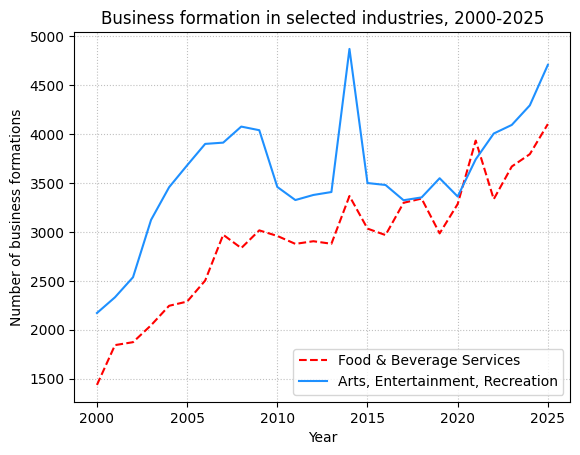

In [15]:
# Plotting multiple lines (Matplotlib approach)
plt.plot(df_wide['Year'], df_wide['Food & Beverage Services'], 
         linestyle='--', color='red', label='Food & Beverage Services')
plt.plot(df_wide['Year'], df_wide['Arts, Entertainment, Recreation'], 
         linestyle='-', color='dodgerblue', label='Arts, Entertainment, Recreation')

# Add Titles and Labels
plt.title('Business formation in selected industries, 2000-2025')
plt.xlabel('Year')
plt.ylabel('Number of business formations')

# Formatting: Add legend and customize grid
plt.legend()
plt.grid(linestyle='dotted', alpha=0.8) # alpha controls grid transparency

# Show plot
plt.show()